In [1]:
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import read_h5ad_file
from cellarium.ml.utilities.data import AnnDataField, densify, categories_to_codes
from cellarium.ml.models import ImputationModel_Gene

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import anndata as ad
import glob
import os
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import shutil
import pickle
import random

from sklearn.model_selection import train_test_split
from cellarium.ml.data.fileio import read_h5ad_file

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

import utils


### CellariumAnnDataDataModule for 10k pbmc count data

In [2]:
data_path = "/Users/aseelawdeh/Documents/stephen_scvi/pbmc_count.h5ad"
adata = read_h5ad_file(data_path)

dm = CellariumAnnDataDataModule(
            dadc = adata,
            batch_keys={
                "x_ng": AnnDataField(attr="raw.X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch",convert_fn=categories_to_codes)
                },
            batch_size=512,
            shuffle=False,
            #shuffle_seed=0
        )

We look at the gene panels from spatials technologies -- and decided that these may be genes we exclude from our analysis to see what the difference in results may look like when when we prevent our model from masking some important genes  

In [4]:
gene_list = pd.read_csv("/Users/aseelawdeh/Documents/stephen_scvi/scripts/gene_panel_summary/intersection_all_panels.txt", header=None)
gene_list = gene_list[0].tolist()
print("Gene list for exclusion from masking:", gene_list)

Gene list for exclusion from masking: ['ABCA1', 'ABCB1', 'ABCC3', 'ABCC4', 'ABCC9', 'ABI3BP', 'ACACB', 'ACE2', 'ACKR3', 'ACP5', 'ACVRL1', 'ADA', 'ADAM12', 'ADAM28', 'ADAM8', 'ADAMTS5', 'ADCY2', 'ADGRE2', 'ADGRE5', 'ADGRG5', 'ADGRG6', 'ADGRL4', 'ADIPOQ', 'ADM', 'ADRA1A', 'ADRA2A', 'ADRB2', 'AGER', 'AGRP', 'AGTR1', 'AGTR2', 'AICDA', 'ALCAM', 'ALK', 'ALOX5', 'ALPK1', 'AMH', 'ANGPT1', 'ANGPT2', 'ANGPTL3', 'ANGPTL4', 'ANK1', 'ANPEP', 'ANXA2', 'AOAH', 'APCDD1', 'APLN', 'APLNR', 'APOB', 'APOL6', 'AQP4', 'AQP9', 'AR', 'ARC', 'ARG1', 'ARX', 'ASCL1', 'ASTN2', 'ATF3', 'AURKB', 'AVPR1A', 'AVPR2', 'AXL', 'BACE2', 'BACH2', 'BAG3', 'BANK1', 'BATF', 'BCAM', 'BCAN', 'BCHE', 'BCL11A', 'BCL11B', 'BCL2', 'BCL2A1', 'BCL6', 'BCL6B', 'BIRC5', 'BIRC7', 'BLK', 'BLNK', 'BMP2', 'BMP2K', 'BMP4', 'BMP5', 'BMP6', 'BMPR1B', 'BNC1', 'BRINP1', 'BRIP1', 'BTK', 'BTLA', 'BTN3A1', 'C1QTNF1', 'C3AR1', 'C5', 'C5AR1', 'C6', 'C8B', 'C8G', 'C9', 'CACNA1B', 'CACNA1C', 'CACNA1D', 'CACNA2D1', 'CACNG4', 'CADM4', 'CALB1', 'CALB2', 

In [5]:
print("Number of genes in gene list:", len(gene_list),
      "\nNumber of genes in dataset:", len(dm.dadc.var_names),
      "\nNumber of genes in gene list that are present in dataset:", len(set(gene_list).intersection(set(dm.dadc.var_names))))

Number of genes in gene list: 1102 
Number of genes in dataset: 4000 
Number of genes in gene list that are present in dataset: 506


In [ ]:
# Train imputation models with different masking probabilities and save predictions in separate folder
masking_prob = 0.5
max_annealing_weights = [0.05, 0.2, 0.5, 0.7, 0.9, 1]
prediction_base_path= f'runs/imputation_wgenelist'

for weight in max_annealing_weights:
    print(f"\nProcessing max annealing weight: {weight}")

    # Create a fresh copy of adata for this max annealing weight
    adata_run = adata.copy()

    # Define imputation module
    imputation_module = CellariumModule(
        model=ImputationModel_Gene(
            var_names_g=dm.dadc.var_names,
            gene_to_exclude_from_masking=gene_list,
            n_batch=10,
            n_latent=20,
            masking_probability=0.5,
            noise2self_ratio_max=0.7,
            noise2self_warmup_epochs=8,
            encoder={
                "hidden_layers": [
                    {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                ],
                "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
            },
            decoder={
                "hidden_layers": [
                    {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                ],
                "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                "final_additive_bias": False,
            },
            dropout_rate=0.1,
            dispersion="gene",
            log_variational=True,
            gene_likelihood="nb",
            latent_distribution="normal"
        ),
        optim_fn=torch.optim.AdamW,
        optim_kwargs={"lr": 1e-4}
    )

   # Train and get predictions for this masking probability
    # Predictions includes: "{name_label}_whole", "{name_label}_masked", "{name_label}_latent_whole", "{name_label}_latent_masked", "{name_label}_masked_gene_indices"
    predictions = utils.train_and_predict_imputation(imputation_module, adata_run, dm, masking_prob, weight, 
                                                     prediction_base_path=prediction_base_path,
                                                     excluded_genes=gene_list,
                                                     epochs=20)
    # mask50_n2s90_masked
    latent_representation = predictions[f"mask{int(masking_prob*100)}_n2s{int(weight*100)}_latent_masked"]
    cell_labels = adata.obs["final_annotation"]

    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(latent_representation, cell_labels, test_size=0.2, random_state=42, stratify=cell_labels)

    # Train the classifiers
    lr_model, rf_model, svm_model = utils.train_classifiers(X_train=X_train, y_train=y_train)
            
    # Evaluate the classifiers
    metrics_df = utils.evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=masking_prob, noise2self_ratio=weight)
    metrics_df.to_csv(f"metrics_parameter_sweep/with_genelist/mask{int(masking_prob*100)}_n2s{int(weight*100)}_parameter_sweep_metrics.csv", index=False)

### Combine metrics per masking prob per n2s together

In [7]:
import pandas as pd 
import glob 

# Load all result files 
files = glob.glob("metrics_parameter_sweep/with_genelist/*.csv")
all_metrics = []
for file in files:
    df = pd.read_csv(file)
    all_metrics.append(df)
metrics_df = pd.concat(all_metrics, ignore_index=True)
metrics_df


,classifier,masking_prob,noise2self_ratio,cell_type,precision,recall,f1_score
0,LR,0.5,1.00,CD10+ B cells,0.952381,0.975610,0.963855
1,LR,0.5,1.00,CD14+ Monocytes,0.954128,0.984227,0.968944
2,LR,0.5,1.00,CD16+ Monocytes,0.500000,0.130435,0.206897
3,LR,0.5,1.00,CD20+ B cells,0.993019,0.989565,0.991289
4,LR,0.5,1.00,CD4+ T cells,0.815011,0.976385,0.888430
...,...,...,...,...,...,...,...
283,SVM,0.5,0.05,Monocyte-derived dendritic cells,0.863636,0.791667,0.826087
284,SVM,0.5,0.05,NK cells,0.869136,0.766885,0.814815
285,SVM,0.5,0.05,NKT cells,0.763345,0.781421,0.772277
286,SVM,0.5,0.05,Plasma cells,0.800000,0.923077,0.857143


In [8]:
macro_n2s = (
    metrics_df
    .groupby(["noise2self_ratio"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)
macro_n2s

,noise2self_ratio,macro_precision,macro_recall,macro_f1,n_cell_types
0,0.05,0.838185,0.752451,0.766507,16
1,0.20,0.819834,0.753165,0.768731,16
2,0.50,0.871420,0.766787,0.781188,16
3,0.70,0.820349,0.738282,0.757569,16
4,0.90,0.819411,0.753676,0.764556,16
5,1.00,0.826721,0.743777,0.758241,16


/var/folders/vv/z6gg91c17fv4f2g9vzyk4hgh0000gn/T/ipykernel_40588/885514654.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Model Type")


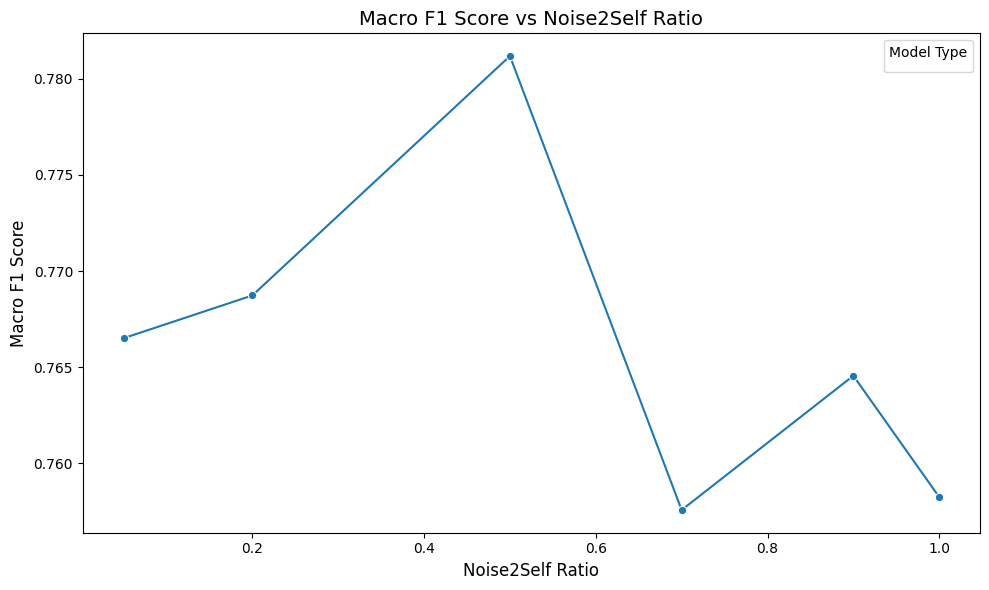

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=macro_n2s, x="noise2self_ratio", y="macro_f1", marker="o")
plt.xlabel("Noise2Self Ratio", fontsize=12)
plt.ylabel("Macro F1 Score", fontsize=12)
plt.title("Macro F1 Score vs Noise2Self Ratio w/Annealing + Excluding Spatial/HVG", fontsize=14)
plt.legend(title="Model Type")
plt.tight_layout()
plt.show()